# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Viet Huynh

**Date:** 6 Sep 2026

In [ ]:
# Your Phase 1 solution to the problem goes here.


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
!git clone https://github.com/viet-huynh-1/A01-data-wrangling.git

fatal: destination path 'A01-data-wrangling' already exists and is not an empty directory.


In [18]:
df1 = pd.read_csv('/content/A01-data-wrangling/data/airbnb_hw.csv', thousands = ',') #originally the prices that would appear would be capped at 999 due to the issue of commas. reading the csv like this makes it so that you don't have to worry about it anymore

In [22]:
df1.head()

,Host Id,Host Since,Name,Neighbourhood,Property Type,Review Scores Rating (bin),Room Type,Zipcode,Beds,Number of Records,Number Of Reviews,Price,Review Scores Rating,Price_nan
0,5162530,NaN,1 Bedroom in Prime Williamsburg,Brooklyn,Apartment,NaN,Entire home/apt,11249.0,1.0,1,0,145,NaN,False
1,33134899,NaN,"Sunny, Private room in Bushwick",Brooklyn,Apartment,NaN,Private room,11206.0,1.0,1,1,37,NaN,False
2,39608626,NaN,Sunny Room in Harlem,Manhattan,Apartment,NaN,Private room,10032.0,1.0,1,1,28,NaN,False
3,500,6/26/2008,Gorgeous 1 BR with Private Balcony,Manhattan,Apartment,NaN,Entire home/apt,10024.0,3.0,1,0,199,NaN,False
4,500,6/26/2008,Trendy Times Square Loft,Manhattan,Apartment,95.0,Private room,10036.0,3.0,1,39,549,96.0,False


In [20]:
df1.dtypes

,0
Host Id,int64
Host Since,object
Name,object
Neighbourhood,object
Property Type,object
Review Scores Rating (bin),float64
Room Type,object
Zipcode,float64
Beds,float64
Number of Records,int64


In [ ]:
#as you can see, reading it this way means that you don't even need to change the dtype

After coercion:
 count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price, dtype: float64 

Total missings:
 0 



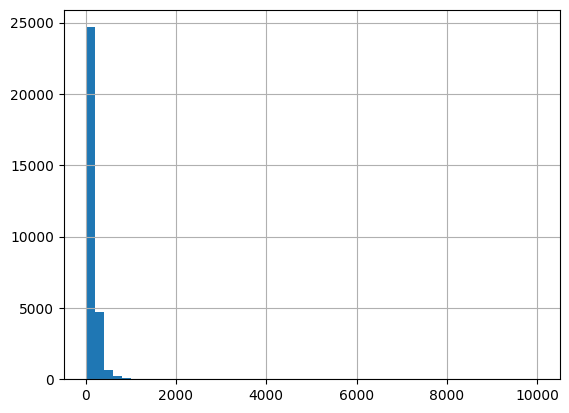

In [21]:
df1['Price'] = pd.to_numeric(df1['Price'], errors='coerce') #but i'll just do it anyway just in case
df1['Price_nan'] = df1['Price'].isnull()

print('After coercion:\n', df1['Price'].describe(), '\n')
df1['Price'].hist(bins=50)
print('Total missings:\n', sum(df1['Price_nan']), '\n')

In [40]:
print(df1.loc[df1['Price'] > 999])

        Host Id Host Since                                 Name  \
101        8730  2/27/2009                Comfort & Convenience   
263       34915  8/30/2009  Luxurious 2-Floor Manhattan Mansion   
764      112879  4/23/2010  Modern Luxury Meets Old Money Charm   
1272     214148  8/26/2010     LARGE, COMFY 1BDR W/CHARACTER!!!   
1275     213266  8/26/2010   Beautiful 1 Bedroom in Nolita/Soho   
...         ...        ...                                  ...   
28951  37155810  6/30/2015         Central Park Luxury : 115916   
28952  37155810  6/30/2015    Central Park South Place : 112756   
28953  37155810  6/30/2015    Central Park South Views : 112754   
28985  37241813   7/1/2015    VERY Spacious 3BR in East Village   
30281  42160989  8/21/2015         Luxury Duplex for Pope Visit   

      Neighbourhood  Property Type  Review Scores Rating (bin)  \
101        Manhattan   Condominium                       100.0   
263        Manhattan     Apartment                         NaN 

In [ ]:
#as you can see the values above triple digits can still showup without much issue

In [24]:
df2 = pd.read_csv('/content/A01-data-wrangling/data/mn_police_use_of_force.csv')
df2.head()

,response_datetime,problem,is_911_call,primary_offense,subject_injury,force_type,force_type_action,race,sex,age,type_resistance,precinct,neighborhood
0,2016/01/01 00:47:36,Assault in Progress,Yes,DASLT1,NaN,Bodily Force,Body Weight to Pin,Black,Male,20.0,Tensed,1,Downtown East
1,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,Black,Female,27.0,Verbal Non-Compliance,1,Downtown West
2,2016/01/01 02:19:34,Fight,No,DISCON,NaN,Chemical Irritant,Personal Mace,White,Female,23.0,Verbal Non-Compliance,1,Downtown West
3,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West
4,2016/01/01 02:28:48,Fight,No,PRIORI,NaN,Chemical Irritant,Crowd Control Mace,Black,Male,20.0,Commission of Crime,1,Downtown West


In [38]:
df2.dtypes

,0
response_datetime,object
problem,object
is_911_call,object
primary_offense,object
subject_injury,object
force_type,object
force_type_action,object
race,object
sex,object
age,float64


In [30]:
df2['subject_injury'].value_counts() #just to see what's going on first

,count
subject_injury,
Yes,1631
No,1446


In [28]:
df2['subject_injury_nan'] = df2['subject_injury'].isnull()
print('Total missings:\n', sum(df2['subject_injury_nan']), '\n') #shows us how many nulls there are

Total missings:
 9848 



In [36]:
#there's definitely too many nulls
df2.loc[df2['subject_injury_nan'] == True, 'subject_injury'] = 'No' #this is just makes it so that every null gets changed into a No
df2['subject_injury'].value_counts()

,count
subject_injury,
No,11294
Yes,1631


In [37]:
df2['subject_injury_nan'] = df2['subject_injury'].isnull()
print('Total missings:\n', sum(df2['subject_injury_nan']), '\n')

Total missings:
 0 



## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]